In [ ]:
# Import pandas for data handling and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import torch for deep learning tensor operations
import torch

# Import seaborn and matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Import Hugging Face dataset loader
from datasets import load_dataset

# Import BERT tokenizer and model for sequence classification
from transformers import BertTokenizer, BertForSequenceClassification

# Import training utilities from Hugging Face
from transformers import TrainingArguments, Trainer

# Import evaluation metrics from sklearn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, classification_report

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

{'text': ['I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far b

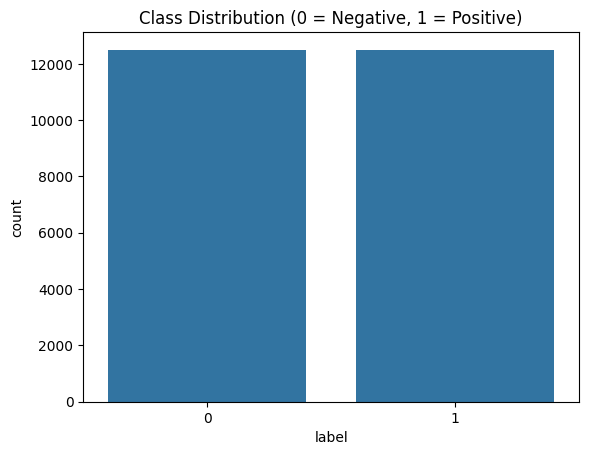

In [ ]:
# Load IMDb dataset from Hugging Face (contains train and test splits)
dataset = load_dataset("imdb")

# Display first 3 records from training dataset
print(dataset["train"][:3])

# Convert training dataset to pandas DataFrame for analysis
df = pd.DataFrame(dataset["train"])

# Print dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Display class distribution (0 = negative, 1 = positive)
print(df["label"].value_counts())

# Plot class distribution to check balance
sns.countplot(x="label", data=df)

# Add title to plot
plt.title("Class Distribution (0 = Negative, 1 = Positive)")

# Show plot
plt.show()

In [ ]:
# Load pre-trained BERT tokenizer (uncased = lowercase text)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Define tokenization function for dataset mapping
def tokenize_function(example):
    # Convert text into input_ids and attention_mask
    return tokenizer(
        example["text"],            # Input review text
        padding="max_length",       # Pad all sequences to same length
        truncation=True,            # Truncate long reviews
        max_length=256              # Set maximum sequence length
    )

# Apply tokenization to entire dataset (batched for speed)
tokenized_dataset = dataset.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# Rename label column to 'labels' for Trainer compatibility
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Set dataset format to PyTorch tensors
tokenized_dataset.set_format(
    type="torch",                              # Convert to torch tensors
    columns=["input_ids", "attention_mask", "labels"]  # Required inputs for BERT
)

# Assign train dataset
train_dataset = tokenized_dataset["train"]

# Assign test dataset
test_dataset = tokenized_dataset["test"]

In [ ]:
# Print number of training samples
print("Train Size:", len(train_dataset))

# Print number of testing samples
print("Test Size:", len(test_dataset))

Train Size: 25000
Test Size: 25000


In [ ]:
# Load BERT model for sequence classification with 2 output labels
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",   # Pre-trained BERT base model
    num_labels=2           # Binary classification (negative, positive)
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Define function to compute evaluation metrics
def compute_metrics(pred):
    # Extract true labels
    labels = pred.label_ids

    # Get predicted class by taking argmax of logits
    preds = pred.predictions.argmax(-1)

    # Compute precision, recall, and F1-score
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    # Compute accuracy
    acc = accuracy_score(labels, preds)

    # Return metrics as dictionary
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",              # Directory to save model outputs
    learning_rate=2e-5,                  # Learning rate for optimizer
    per_device_train_batch_size=8,       # Batch size for training
    per_device_eval_batch_size=8,        # Batch size for evaluation
    num_train_epochs=2,                  # Number of training epochs
    # evaluation_strategy="epoch",         # Evaluate after each epoch
    save_strategy="epoch",               # Save model after each epoch
    logging_dir="./logs",                # Directory for logs
    # load_best_model_at_end=True          # Load best model based on evaluation
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# Initialize Trainer with model, arguments, datasets, tokenizer, and metrics
trainer = Trainer(
    model=model,                         # BERT classification model
    args=training_args,                  # Training configuration
    train_dataset=train_dataset,         # Training data
    eval_dataset=test_dataset,           # Evaluation data
    compute_metrics=compute_metrics      # Evaluation metrics function
)

# Start model training
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Step,Training Loss


In [ ]:
# Predict on test dataset
predictions = trainer.predict(test_dataset)

# Extract true labels
y_true = predictions.label_ids

# Extract predicted labels
y_pred = np.argmax(predictions.predictions, axis=1)

# Print classification report (precision, recall, F1, accuracy)
print(classification_report(y_true, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create confusion matrix plot
plt.figure(figsize=(6,5))

# Plot heatmap of confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

# Label axes
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add title
plt.title("Confusion Matrix - BERT IMDb")

# Show plot
plt.show()